# Fairness Visualization

This notebook provides a compact, publication-oriented view of the fairness audit outputs. It loads the saved JSON artifacts and previews the exported figure set without recomputing the full pipeline.

## Core trade-off summary

,artifact,accuracy,far,frr
0,initial_model,0.523,0.325,0.629
1,mitigated_model,0.506,0.519,0.469


**Fairness risk:** HIGH

**Worst subgroup FRR:** Male_0-19_Light = 0.718

**Worst subgroup FAR:** Male_60+_Dark = 0.000

**Average disparity reduction:** 0.105

**Best improved subgroup:** Female_40-59_Light

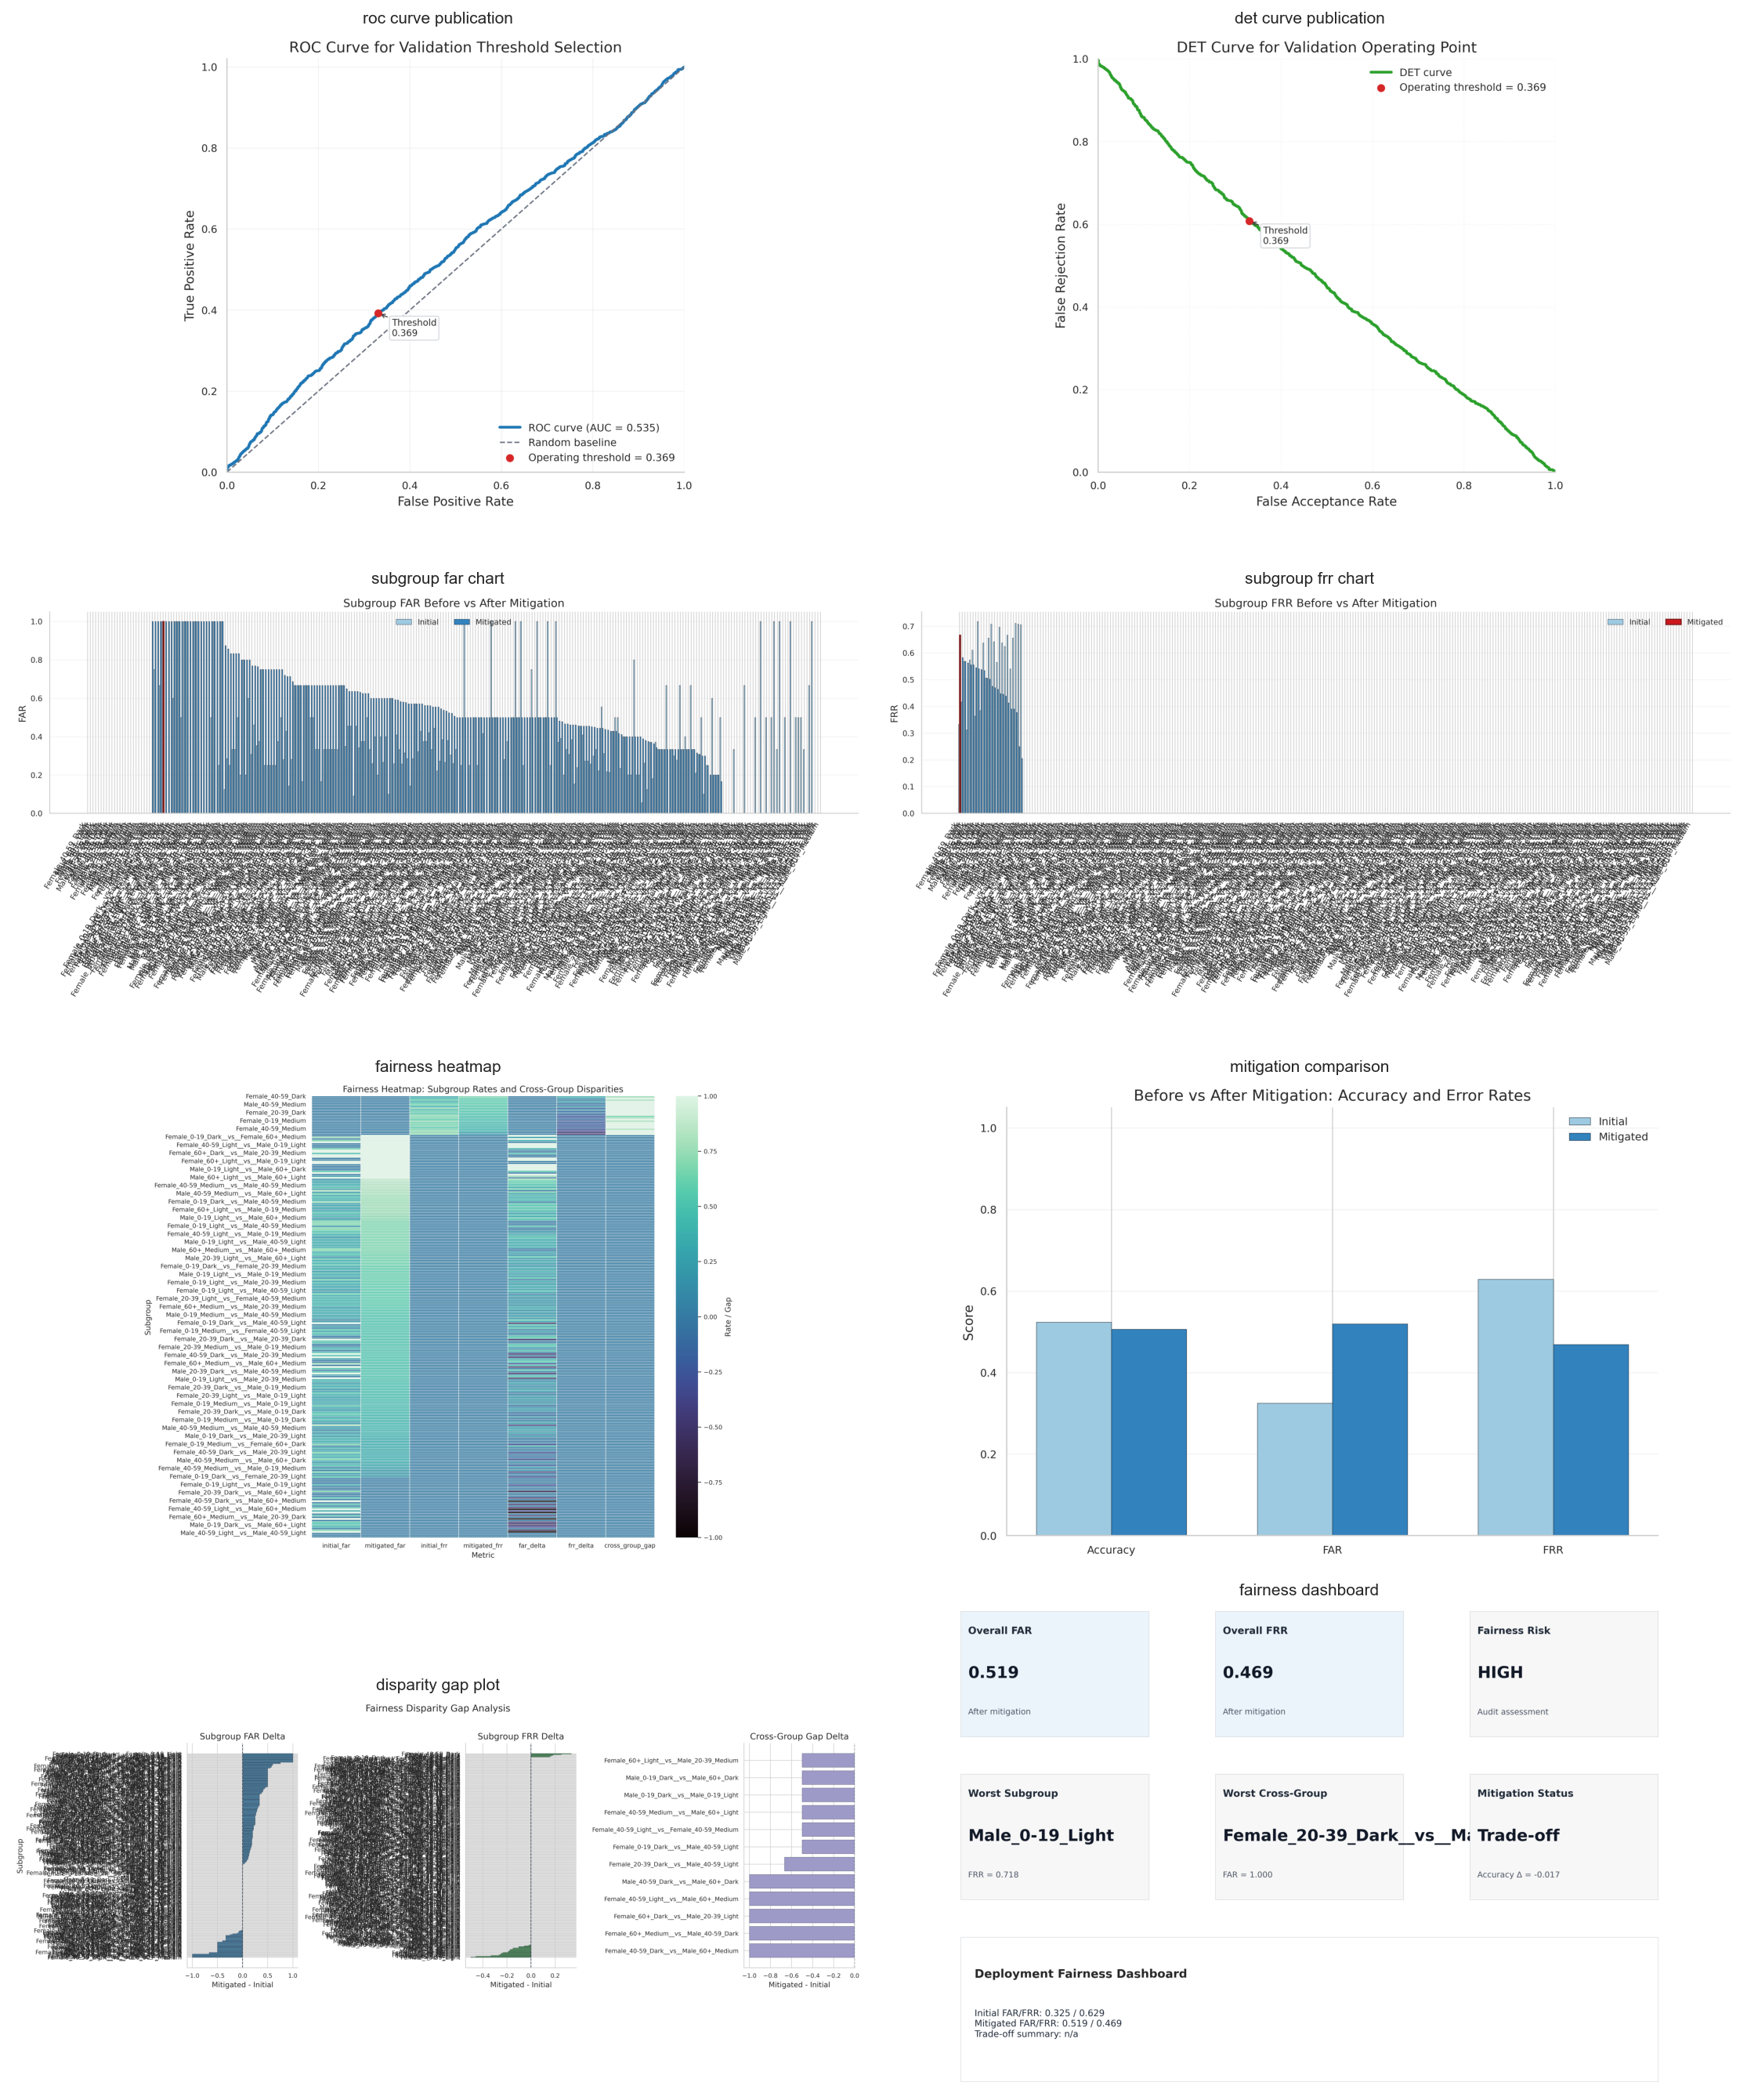

In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

root = Path.cwd()
if not (root / "results").exists():
    root = root.parent

results = root / "results"
plots = root / "artifacts" / "plots"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300, "font.size": 11})


def load_json(name: str) -> dict:
    with (results / name).open("r", encoding="utf-8") as handle:
        return json.load(handle)


fairness_summary = load_json("fairness_summary.json")
fairness_comparison = load_json("fairness_comparison.json")
overall_metrics = load_json("overall_metrics.json")

summary_df = pd.DataFrame(
    [
        {
            "artifact": "initial_model",
            "accuracy": overall_metrics["initial_model"]["accuracy"],
            "far": overall_metrics["initial_model"]["far"],
            "frr": overall_metrics["initial_model"]["frr"],
        },
        {
            "artifact": "mitigated_model",
            "accuracy": overall_metrics["mitigated_model"]["accuracy"],
            "far": overall_metrics["mitigated_model"]["far"],
            "frr": overall_metrics["mitigated_model"]["frr"],
        },
    ]
)

display(Markdown("## Core trade-off summary"))
display(summary_df.style.format({"accuracy": "{:.3f}", "far": "{:.3f}", "frr": "{:.3f}"}))
display(Markdown(f"**Fairness risk:** {fairness_summary['fairness_risk_level']}"))
display(Markdown(f"**Worst subgroup FRR:** {fairness_summary['worst_frr_group']['group']} = {fairness_summary['worst_frr_group']['frr']:.3f}"))
display(Markdown(f"**Worst subgroup FAR:** {fairness_summary['worst_far_group']['group']} = {fairness_summary['worst_far_group']['far']:.3f}"))
display(Markdown(f"**Average disparity reduction:** {fairness_comparison['average_disparity_reduction']:.3f}"))
display(Markdown(f"**Best improved subgroup:** {fairness_comparison['best_improved_subgroup']}"))

figure_paths = [
    "roc_curve_publication.png",
    "det_curve_publication.png",
    "subgroup_far_chart.png",
    "subgroup_frr_chart.png",
    "fairness_heatmap.png",
    "mitigation_comparison.png",
    "disparity_gap_plot.png",
    "fairness_dashboard.png",
]

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.ravel()

for axis, name in zip(axes, figure_paths):
    image_path = plots / name
    axis.imshow(plt.imread(image_path))
    axis.set_title(name.replace("_", " ").replace(".png", ""), fontsize=10)
    axis.axis("off")

plt.tight_layout()
plt.show()